# Particle Filter Debug Graphs
Uses collected data from a particle filter run to visualize what could be wrong.

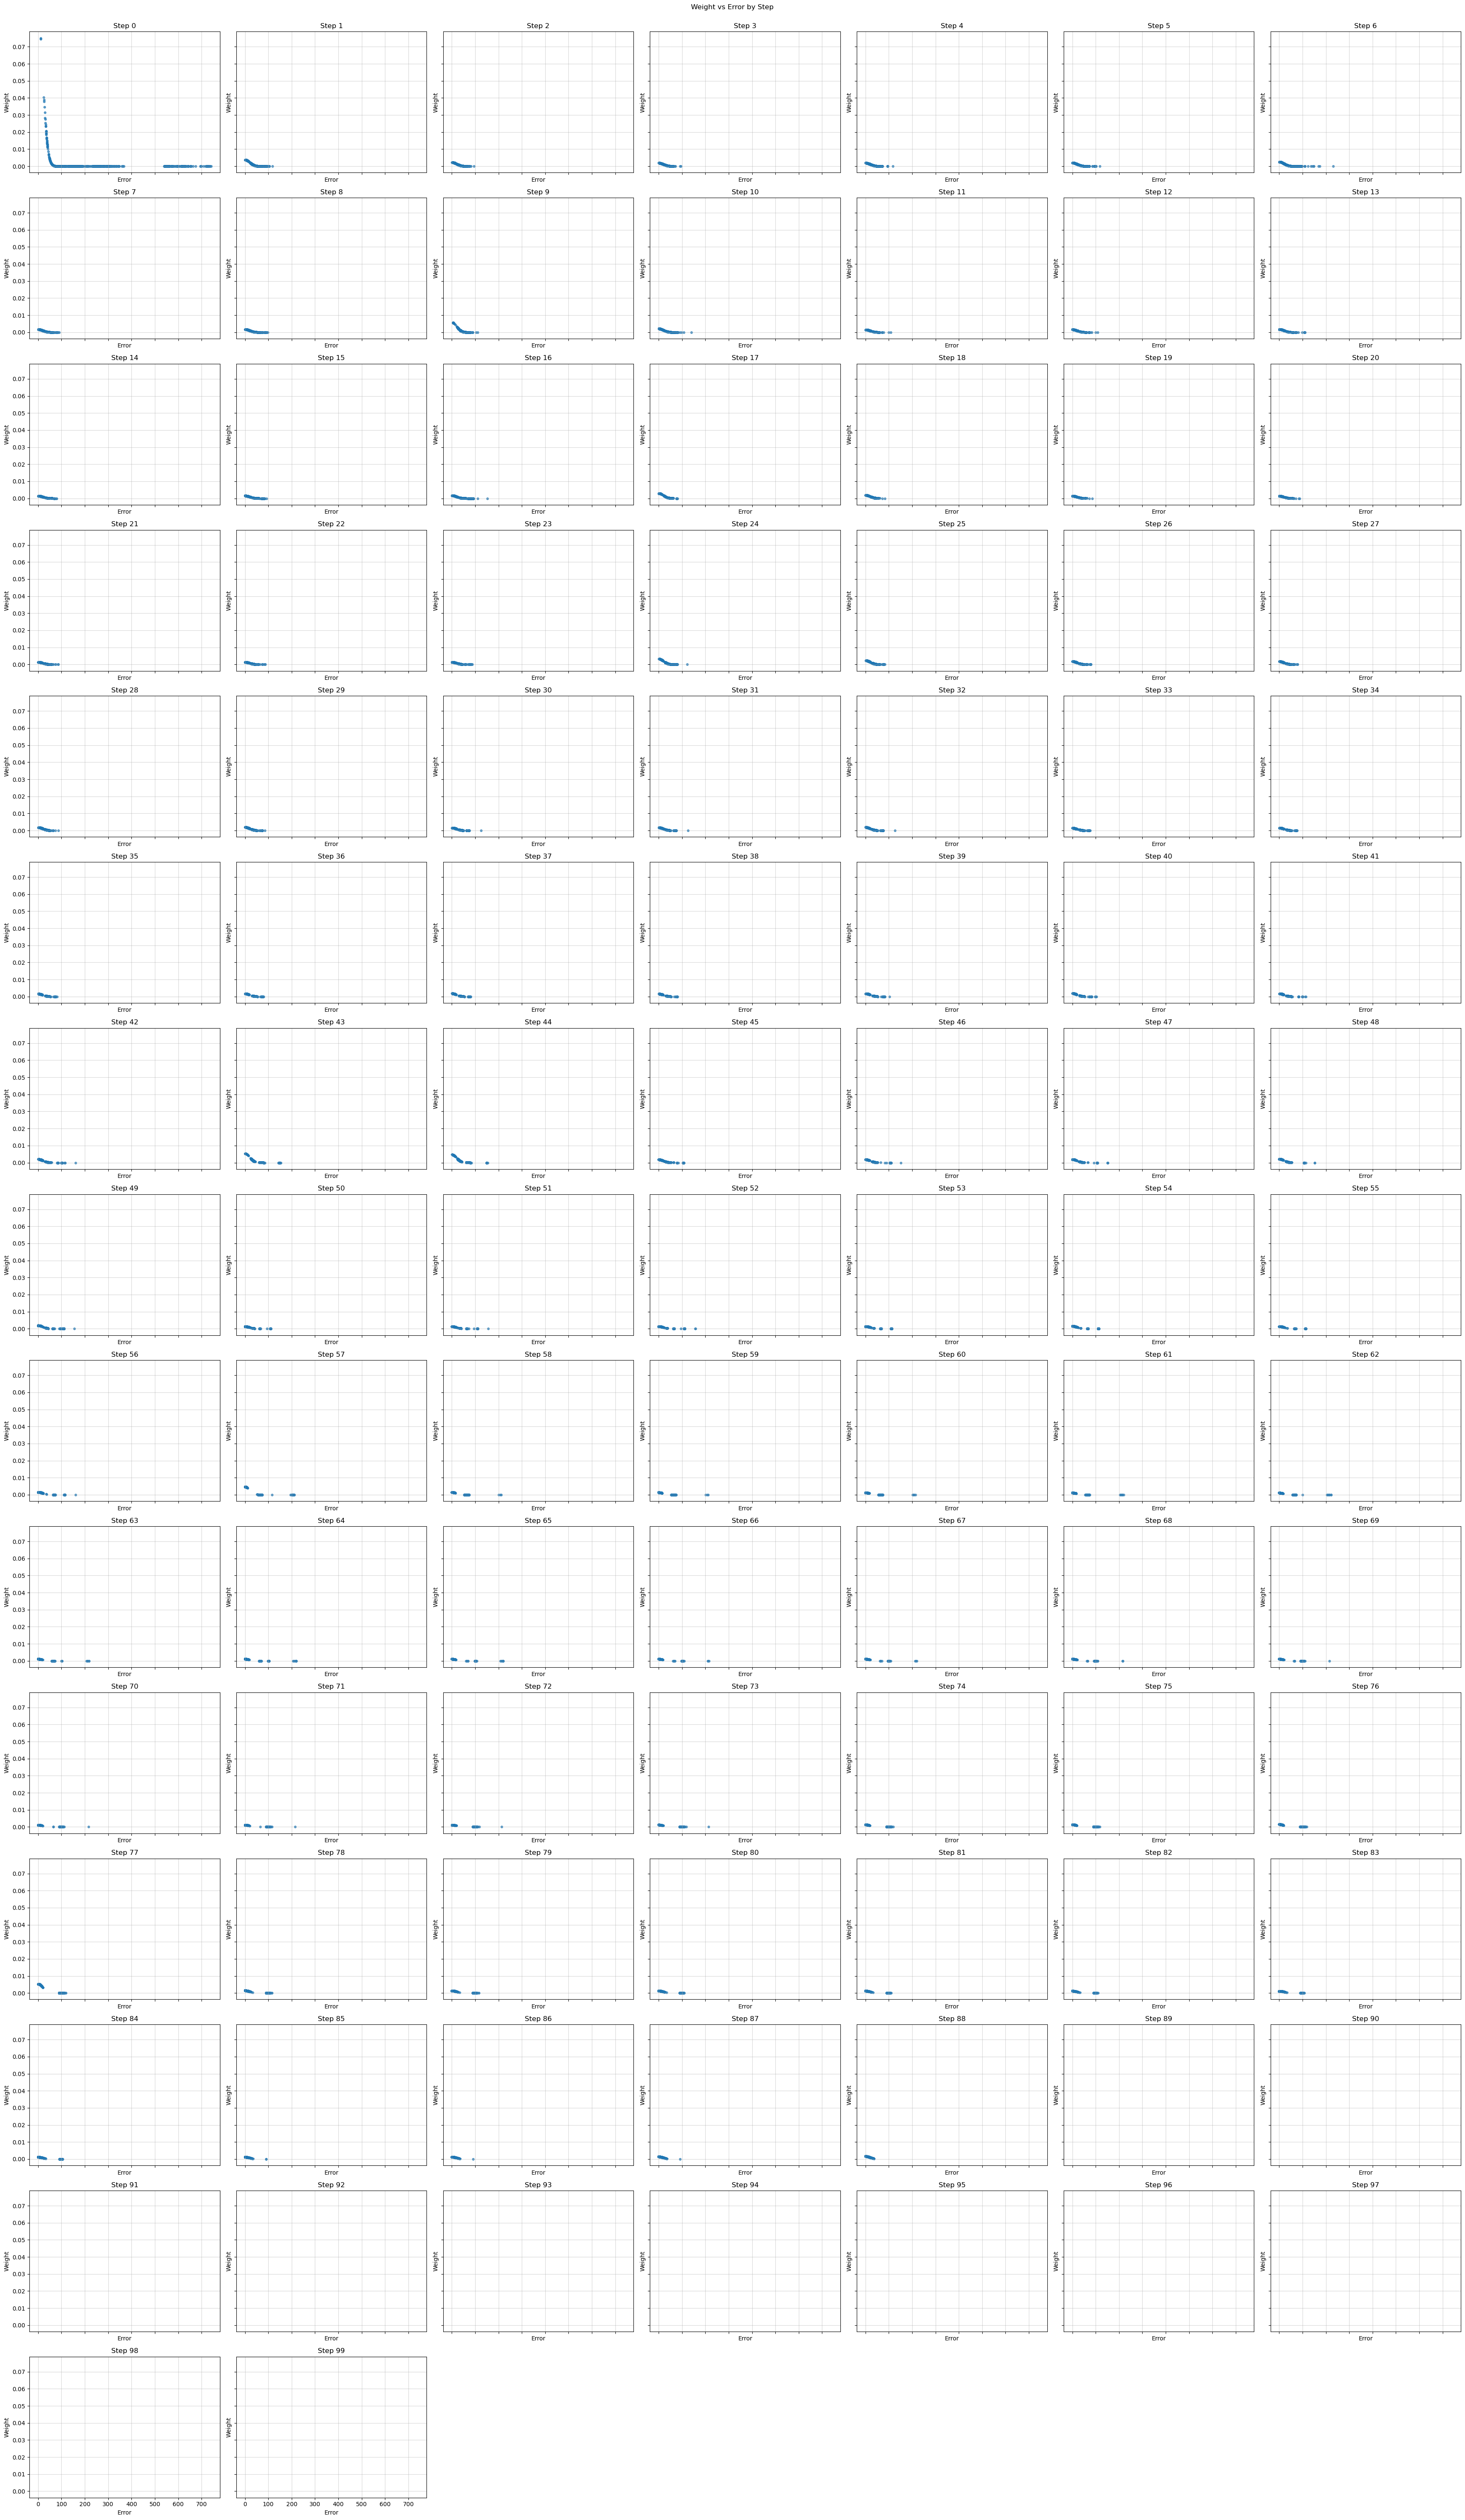

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from vis_loc.field import Field
from vis_loc.localize import Localize

field = Field()
loc = Localize(100, 80)

csv_path = "logs/particle_log_20261009_185441.csv"
df = pd.read_csv(csv_path)

if df.empty:
    print(f"No data found in {csv_path}")
else:
    steps = sorted(df["step"].unique())
    n_steps = len(steps)
    cols = 6
    rows = int(np.ceil(n_steps / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharex=True, sharey=True)
    axes = axes.flatten() if n_steps > 1 else [axes]

    for ax, step in zip(axes, steps):
        step_df = df[df["step"] == step]
        ax.scatter(step_df["error"], step_df["weight"], s=12, alpha=0.7) # type: ignore
        ax.set_title(f"Step {step}") # type: ignore
        ax.set_xlabel("Error") # type: ignore
        ax.set_ylabel("Weight") # type: ignore
        ax.grid(True, alpha=0.5) # type: ignore

    for ax in axes[n_steps:]:
        ax.axis("off") # type: ignore

    fig.suptitle("Weight vs Error by Step", y=1)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

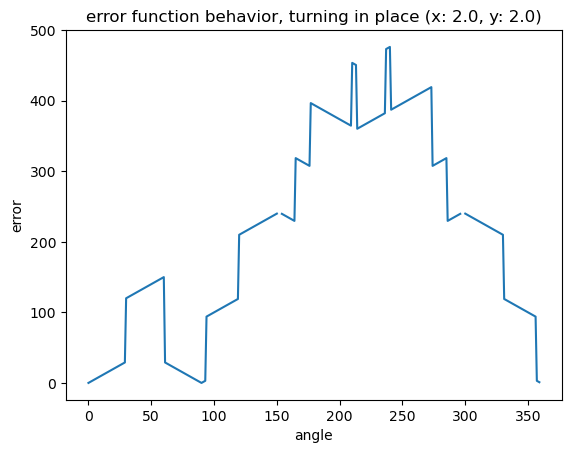

In [4]:
# error function debug
from vis_loc.field import Field
from vis_loc.localize import Localize
import matplotlib.pyplot as plt

field = Field()
loc = Localize(200, 90)

def err_360():
    angle = []
    fn_out = []

    coords = (2.0, 2.0) # x, y

    for i in range(360):
        obs = field.predicted_output((coords[0], coords[1], 0), 120, 12)
        p = field.predicted_output((coords[0], coords[1], i), 120, 12)
        error = loc.calc_error(p, obs)
        fn_out.append(error) 
        angle.append(i)

    # debug plotting
    plt.plot(angle, fn_out)

    plt.xlabel('angle')
    plt.ylabel('error')
    plt.title('error function behavior, turning in place (x: 2.0, y: 2.0)')

err_360()
